<a href="https://colab.research.google.com/github/amiralirh/Diabetic-Retinopathy-Detection/blob/main/DR_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model as KerasModel
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import seaborn as sns
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from sklearn.manifold import TSNE



##  Directory Configuration and Data Transfer


In [ ]:
import os

# --- Define source paths on Google Drive ---
SOURCE_DATA_DIR_ON_DRIVE = '/content/drive/MyDrive/Aptos'
LOCAL_DATA_DIR_ON_COLAB = '/content/aptos_local_data'
LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'preprocessed_train_images')
LOCAL_TEST_IMAGES_DIR = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'test_images')

# --- Copy data from Google Drive to Colab local storage ---
print(f"Copying data from Google Drive ({SOURCE_DATA_DIR_ON_DRIVE}) to Colab local storage ({LOCAL_DATA_DIR_ON_COLAB})...")
os.makedirs(LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR, exist_ok=True)
os.makedirs(LOCAL_TEST_IMAGES_DIR, exist_ok=True)
!rsync -avh "$SOURCE_DATA_DIR_ON_DRIVE/preprocessed_train_images/" "$LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR/"
!rsync -avh "$SOURCE_DATA_DIR_ON_DRIVE/test_images/" "$LOCAL_TEST_IMAGES_DIR/"
!cp "$SOURCE_DATA_DIR_ON_DRIVE/train.csv" "$LOCAL_DATA_DIR_ON_COLAB/train.csv"
!cp "$SOURCE_DATA_DIR_ON_DRIVE/test.csv" "$LOCAL_DATA_DIR_ON_COLAB/test.csv"
print("Data copy to Colab local storage completed.")

# --- Set paths to point to local Colab folders ---
train_csv_path = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'train.csv')
preprocessed_train_image_dir = LOCAL_PREPROCESSED_TRAIN_IMAGES_DIR
test_csv_path = os.path.join(LOCAL_DATA_DIR_ON_COLAB, 'test.csv')
test_image_dir = LOCAL_TEST_IMAGES_DIR

در حال کپی کردن داده ها از Google Drive (/content/drive/MyDrive/Aptos) به حافظه محلی Colab (/content/aptos_local_data)...
sending incremental file list
./
000c1434d8d7.png
001639a390f0.png
0024cdab0c1e.png
002c21358ce6.png
005b95c28852.png
0083ee8054ee.png
0097f532ac9f.png
00a8624548a9.png
00b74780d31d.png
00cb6555d108.png
00cc2b75cddd.png
00e4ddff966a.png
00f6c1be5a33.png
0104b032c141.png
0124dffecf29.png
0125fbd2e791.png
012a242ac6ff.png
014508ccb9cb.png
0151781fe50b.png
0161338f53cc.png
0180bfa26c0b.png
0182152c50de.png
01b3aed3ed4c.png
01c7808d901d.png
01d9477b1171.png
01eb826f6467.png
01f7bb8be950.png
0212dd31f623.png
022f820027b8.png
0231642cf1c2.png
0232dfea7547.png
02358b47ea89.png
0243404e8a00.png
025a169a0bb0.png
02685f13cefd.png
026dcd9af143.png
02cd34a85b24.png
02da652c74b8.png
02dda30d3acf.png
0304bedad8fe.png
0318598cfd16.png
032d7b0b4bf6.png
033f2b43de6d.png
034cb07a550f.png
03676c71ed1b.png
0369f3efe69b.png
03747397839f.png
03a7f4a5786f.png
03b373718013.png
03c85870824c

##  Data Split

To accurately evaluate the model's ability to generalize to unseen data, we must partition our dataset into a training set and a validation holdout set.

This cell utilizes Scikit-Learn's `train_test_split` function to allocate 80% of the images for model training and reserve 20% for validation.

**The Importance of Stratification:**
The APTOS dataset suffers from severe class imbalance, with a vast majority of healthy retinas (Class 0) and very few severe cases (Classes 3 and 4). If we were to split the data randomly, we run the risk of creating a validation set that contains zero examples of the minority classes.

By enforcing `stratify=df_train['diagnosis']`, we guarantee that the original distribution of Diabetic Retinopathy severity grades is perfectly preserved in both the training and validation sets. This ensures our evaluation metrics during training accurately reflect the model's performance across all stages of the disease. A fixed `random_state` is also set to ensure experimental reproducibility.

In [ ]:
# --- 1. Load and prepare data ---
df_train = pd.read_csv(train_csv_path)
df_train['id_code'] = df_train['id_code'].apply(lambda x: x + '.png')
train_df, val_df = train_test_split(df_train, test_size=0.2, stratify=df_train['diagnosis'], random_state=42)
print(f"\nNumber of training images: {len(train_df)}")
print(f"Number of validation images: {len(val_df)}")


تعداد تصاویر آموزشی: 2929
تعداد تصاویر اعتبارسنجی: 733


##  Data Pipeline and Augmentation (tf.data)

To maximize GPU utilization and ensure smooth, bottleneck-free training, this cell constructs a highly optimized Extract-Transform-Load (ETL) pipeline using the `tf.data.Dataset` API. Rather than loading all images into RAM at once, this approach dynamically reads, processes, and batches data on the CPU while the GPU is busy training the previous batch.

**Key Components of the Pipeline:**

* **Data Loading and Formatting:** Images are read from disk, decoded, resized to the target tensor dimensions (224x224), and normalized using a specific `preprocess_input` function (which scales pixel values to the range expected by our chosen pre-trained architecture).
* **Targeted Data Augmentation:** A custom augmentation function applies random transformations to artificially expand the training dataset and prevent overfitting.
    * **Geometric:** Random horizontal/vertical flips and 90-degree rotations are applied, which are biologically plausible for retinal images.
    * **Photometric:** Slight, conservative adjustments to brightness (±10%) and contrast (±10%) are introduced. *Crucially, hue and saturation shifts have been removed.* In medical imaging, the specific color of a lesion (e.g., bright yellow hard exudates vs. dark red hemorrhages) carries vital diagnostic information; altering the hue could inadvertently destroy these clinical features.
* **Pipeline Optimization:**
    * `.map(num_parallel_calls=tf.data.AUTOTUNE)`: Parallelizes the preprocessing and augmentation steps across available CPU cores.
    * `.cache()`: Stores the preprocessed images in memory after the first epoch, eliminating disk I/O latency for all subsequent epochs.
    * `.prefetch(tf.data.AUTOTUNE)`: The most critical optimization; it prepares the next batch of data in the background while the current batch is being processed by the GPU.

**Addressing Class Imbalance via Cost-Sensitive Learning:**
The APTOS dataset is notoriously skewed towards healthy retinas. To prevent the model from simply predicting "Class 0" for every image and achieving a misleadingly high accuracy, we define a **Custom Class Weights Dictionary**.
By assigning a much higher penalty weight to the severe minority classes (Classes 1-4) and a lower weight to the dominant Class 0 (0.40), we force the loss function to heavily prioritize learning the features of the diseased retinas, directly addressing issues identified in prior confusion matrix analyses.

In [ ]:
# --- Image parameters ---
IMG_WIDTH = 224
IMG_HEIGHT = 224
BATCH_SIZE = 32
NUM_CLASSES = 5

def load_and_preprocess_image_tf(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = tf.cast(img, tf.float32)
    img = preprocess_input(img)
    return img, label

def augment_data_tf(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.08)
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    if tf.random.uniform(shape=[]) > 0.5:
        crop_height = tf.cast(tf.round(tf.cast(IMG_HEIGHT, tf.float32) * tf.random.uniform([], minval=0.9, maxval=1.0)), tf.int32)
        crop_width = tf.cast(tf.round(tf.cast(IMG_WIDTH, tf.float32) * tf.random.uniform([], minval=0.9, maxval=1.0)), tf.int32)
        crop_height = tf.maximum(tf.constant(1, dtype=tf.int32), tf.minimum(crop_height, IMG_HEIGHT))
        crop_width = tf.maximum(tf.constant(1, dtype=tf.int32), tf.minimum(crop_width, IMG_WIDTH))
        image = tf.image.random_crop(image, size=[crop_height, crop_width, 3])
        image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return image, label

train_image_paths = [os.path.join(preprocessed_train_image_dir, img_id) for img_id in train_df['id_code'].values]
train_labels = train_df['diagnosis'].values
val_image_paths = [os.path.join(preprocessed_train_image_dir, img_id) for img_id in val_df['id_code'].values]
val_labels = val_df['diagnosis'].values

train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))
validation_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_labels))

train_dataset = train_dataset.map(load_and_preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.map(load_and_preprocess_image_tf, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = train_dataset.map(augment_data_tf, num_parallel_calls=tf.data.AUTOTUNE)

train_dataset = train_dataset.cache()
validation_dataset = validation_dataset.cache()

train_dataset = train_dataset.shuffle(buffer_size=1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("\nDatasets successfully created with file paths and built-in Data Augmentation (tf.data).")

# --- Calculate Class Weights ---
class_weights_dict = {
    0: 0.40,
    1: 7.0,
    2: 6.0,
    3: 8.0,
    4: 6.0
}
print("\nCustomized weights for each class:")
print(class_weights_dict)


Datasets با موفقیت از مسیرهای فایل و با Data Augmentation داخلی (tf.data) ایجاد شدند.

وزن های سفارشی شده برای هر کلاس:
{0: 0.4, 1: 7.0, 2: 6.0, 3: 8.0, 4: 6.0}


##  Model Architecture: EfficientNetB0 and Advanced Regularization

*Note: This cell replaces the previous ResNet50 architecture with a more modern, highly optimized network and introduces stricter regularization techniques.*

Training deep neural networks on specialized, highly imbalanced medical datasets often leads to severe overfitting. To combat this, this architectural update transitions the feature extractor to **EfficientNetB0** and applies aggressive regularization strategies to the custom classification head.

**Architectural Strategy and Key Upgrades:**

* **Feature Extractor (EfficientNetB0):** Unlike traditional architectures that scale up by arbitrarily adding layers (depth) or filters (width), EfficientNet uses a mathematically principled compound scaling method. It achieves better or comparable accuracy to heavy models (like ResNet) while requiring significantly fewer parameters. The base layers are loaded with ImageNet weights and **frozen** to preserve their fundamental visual feature-extraction capabilities during the initial training phase.
* **Custom Classification Head with Strong Regularization:**
    * **Global Average Pooling 2D (GAP):** Reduces spatial dimensions and acts as a structural regularizer, avoiding the massive parameter explosion that occurs with standard `Flatten` layers.
    * **L2 Regularization (Weight Decay):** An L2 penalty (`kernel_regularizer=l2(0.005)`) has been applied to both the hidden Dense layer and the final output layer. This mathematically penalizes excessively large network weights, forcing the model to learn a simpler, more generalized representation of Diabetic Retinopathy features rather than memorizing exact training samples.
    * **Aggressive Dropout (0.65):** The dropout rate has been increased to a highly restrictive 65%. By randomly disabling nearly two-thirds of the neurons in the dense layer during every training step, the network is forced to learn highly redundant and robust biomarkers, preventing it from relying on a few dominant (but potentially noisy) pixels.
* **Optimized Compilation:** The network is compiled using the Adam optimizer with a deliberately conservative initial learning rate of `0.0001`. This smaller step size ensures that the newly initialized, highly regularized dense layers converge smoothly without inducing chaotic gradient updates.

In [ ]:
# --- 2. Model Design and Construction ---
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(0.005))(x)
x = Dropout(0.65)(x)
predictions = Dense(NUM_CLASSES, activation='softmax', kernel_regularizer=l2(0.005))(x)

model = KerasModel(inputs=base_model.input, outputs=predictions)
initial_learning_rate = 0.0001
model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"\n--- Model Summary (Initial Training) ---")
model.summary()


--- خلاصه مدل (آموزش اولیه) ---


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

##  Extended Two-Phase Training and  Fine-Tuning

Because the updated architecture employs a highly restrictive regularization strategy (65% Dropout and L2 weight decay), the network requires significantly more iterations to properly converge. This cell executes an extended two-phase training protocol, designed to safely adapt the EfficientNetB0 feature extractor to our dataset without triggering catastrophic forgetting.

**Phase 1: Classification Head Warm-up (Initial Training - 30 Epochs)**
* During this prolonged initial phase, the EfficientNetB0 base remains completely **frozen**.
* The optimizer focuses exclusively on updating the weights of our newly added Dense layers.
* Because of the heavy regularization applied in the previous step, a longer warm-up period (30 epochs) is required for the classification head to learn a stable, initial mapping from the extracted ImageNet features to our specific Diabetic Retinopathy grades.
* The `class_weights_dict` is applied to continuously penalize errors on the critical minority classes (Severe and Proliferative DR).

**Phase 2: End-to-End Fine-Tuning (40 Epochs)**
* Once the top layers have achieved structural stability, the entire EfficientNetB0 network is **unfrozen** (`layer.trainable = True`).
* The model is recompiled with a highly constrained learning rate of `1e-05`.
* During this intensive 40-epoch phase, the optimizer makes microscopic adjustments across the entire network architecture. This allows the deeper convolutional filters to shift their focus away from generic ImageNet objects and specialize entirely in detecting complex retinal pathologies.

**Dynamic Safeguards (Callbacks):**
With a combined maximum of 70 epochs, the risk of overfitting is elevated. We rely on two critical callbacks to actively govern the training loop:
* **ReduceLROnPlateau (`patience=15`):** If the validation accuracy stalls, the learning rate is halved. This acts as an automated "learning rate decay," allowing the model to take progressively smaller steps to settle into the optimal minimum.
* **Early Stopping (`patience=20`):** Continuously monitors the `val_accuracy`. If the model fails to improve for 20 consecutive epochs, training is prematurely halted, and the weights from the absolute best-performing epoch are restored (`restore_best_weights=True`), ensuring we capture the model at its peak generalization capability.

In [ ]:
# --- 3. Model Training ---
early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max', verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=15, min_lr=1e-08, mode='max', verbose=1)

EPOCHS_INITIAL = 30
print(f"\n--- Starting Initial Training for {EPOCHS_INITIAL} Epochs ---")
history_initial = model.fit(
    train_dataset,
    epochs=EPOCHS_INITIAL,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

print("\n--- Starting Fine-tuning stage ---")
for layer in base_model.layers:
    layer.trainable = True

fine_tune_learning_rate = 1e-05
model.compile(optimizer=Adam(learning_rate=fine_tune_learning_rate),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"\nModel recompiled with learning rate {fine_tune_learning_rate} for Fine-tuning.")
print(f"--- Model Summary (After Fine-tuning) ---")
model.summary()

EPOCHS_FINE_TUNE = 40
print(f"\nStarting Fine-tuning for {EPOCHS_FINE_TUNE} Epochs...")
history_fine_tune = model.fit(
    train_dataset,
    epochs=EPOCHS_FINE_TUNE,
    validation_data=validation_dataset,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

print("\n--- Fine-tuning stage completed ---")


--- شروع آموزش اولیه برای 30 Epoch ---
Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.6243 - loss: 4.6661 - val_accuracy: 0.6917 - val_loss: 2.6051 - learning_rate: 1.0000e-05
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step - accuracy: 0.6335 - loss: 4.4595 - val_accuracy: 0.6985 - val_loss: 2.5873 - learning_rate: 1.0000e-05
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.6517 - loss: 4.4990 - val_accuracy: 0.6999 - val_loss: 2.5743 - learning_rate: 1.0000e-05
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.6652 - loss: 4.3966 - val_accuracy: 0.7026 - val_loss: 2.5592 - learning_rate: 1.0000e-05
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.6886 - loss: 4.3147 - val_accuracy: 0.7012 - val_loss: 2.5542 - learning_rate: 1.0000e-05
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.6919 - loss: 4.1963 - val_accuracy: 0.7053 - val_loss: 2.5450 - learning_rate: 1.0000e-05
Epoch 7/30
92/92 ━

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,378,792 (16.70 MB)

 Trainable params: 4,336,769 (16.54 MB)

 Non-trainable params: 42,023 (164.16 KB)


در حال شروع Fine-tuning برای 40 Epoch...
Epoch 1/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 133s 678ms/step - accuracy: 0.8570 - loss: 2.6968 - val_accuracy: 0.7599 - val_loss: 2.4559 - learning_rate: 1.0000e-05
Epoch 2/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.8788 - loss: 2.5294 - val_accuracy: 0.7585 - val_loss: 2.4588 - learning_rate: 1.0000e-05
Epoch 3/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8782 - loss: 2.5788 - val_accuracy: 0.7599 - val_loss: 2.4594 - learning_rate: 1.0000e-05
Epoch 4/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.8709 - loss: 2.6025 - val_accuracy: 0.7585 - val_loss: 2.4612 - learning_rate: 1.0000e-05
Epoch 5/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 141ms/step - accuracy: 0.8707 - loss: 2.5893 - val_accuracy: 0.7613 - val_loss: 2.4631 - learning_rate: 1.0000e-05
Epoch 6/40
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.8806 - loss: 2.5041 - val_accuracy: 0.7626 - val_loss: 2.4617 - learning_rate: 1.0000e-05
Epoch 7/40
92/9

##  Comprehensive Model Evaluation

Following the extended fine-tuning of the EfficientNetB0 architecture, this cell executes a rigorous suite of evaluations to quantify the model's diagnostic accuracy and verify the quality of its learned feature representations.

**1. Training Dynamics (Learning Curves)**
The evaluation begins by plotting the accuracy and loss histories across the fine-tuning epochs. By analyzing the convergence of the training and validation curves, we can visually confirm the efficacy of our aggressive regularization strategy (65% Dropout and L2 Weight Decay) and ensure the model has not overfitted to the training data.

**2. Clinical Error Analysis**
* **Classification Report:** Generates a detailed breakdown of Precision, Recall, and F1-Score for each specific DR grade. High recall in the severe classes (3 and 4) is critical, as missing an advanced case of Diabetic Retinopathy carries severe clinical consequences.
* **Confusion Matrix:** Displays a heatmap of the model's predictions versus the actual ground truth. In medical grading tasks, the *magnitude* of the error is paramount. A robust model should have most of its misclassifications clustered tightly along the diagonal (e.g., confusing "Mild" with "Moderate"), avoiding catastrophic errors (e.g., predicting "No DR" for a "Proliferative" case).

**3. Official Competition Metric (Quadratic Weighted Kappa)**
The cell calculates **Cohen's Kappa Score** utilizing `weights='quadratic'`. This is the definitive metric for the APTOS dataset. It calculates the inter-rater agreement between the AI's predictions and the human clinicians' labels, applying a severe mathematical penalty for predictions that fall far from the true severity grade.

**4. Latent Space Visualization (t-SNE)**
To verify that our EfficientNetB0 model is learning distinct biological pathologies rather than memorizing random pixel noise, we extract the high-dimensional feature vectors directly from the network's top convolutional layer (`Top_Conv`).
Using **t-Distributed Stochastic Neighbor Embedding (t-SNE)**, we project these complex features into a 2-dimensional scatter plot.
* Distinct, cohesive color clusters indicate that the model successfully differentiates the specific visual biomarkers corresponding to each stage of the disease.
* A gradual spatial progression across the clusters generally reflects the biological progression from a healthy retina (Class 0) to advanced Proliferative DR (Class 4).

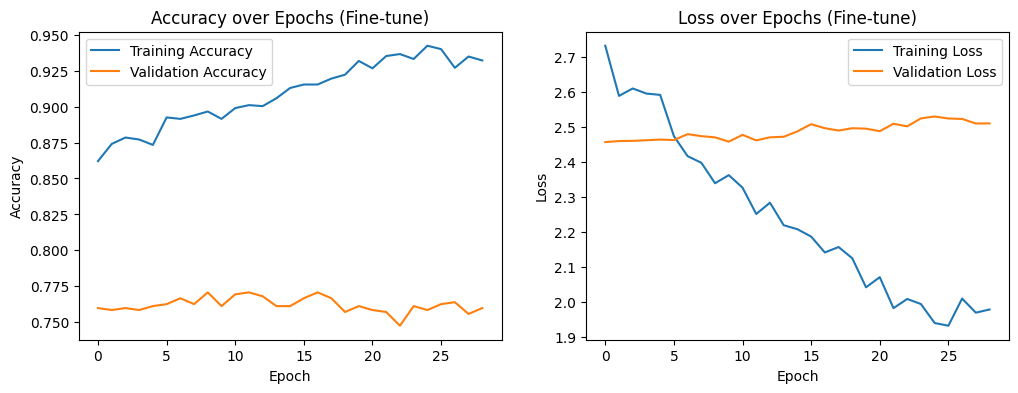


--- ارزیابی نهایی مدل ---
23/23 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step

گزارش طبقه‌بندی نهایی:
              precision    recall  f1-score   support

           0       0.98      0.88      0.92       361
           1       0.40      0.61      0.48        74
           2       0.72      0.82      0.77       200
           3       0.52      0.44      0.47        39
           4       0.62      0.39      0.48        59

    accuracy                           0.77       733
   macro avg       0.65      0.63      0.62       733
weighted avg       0.80      0.77      0.78       733



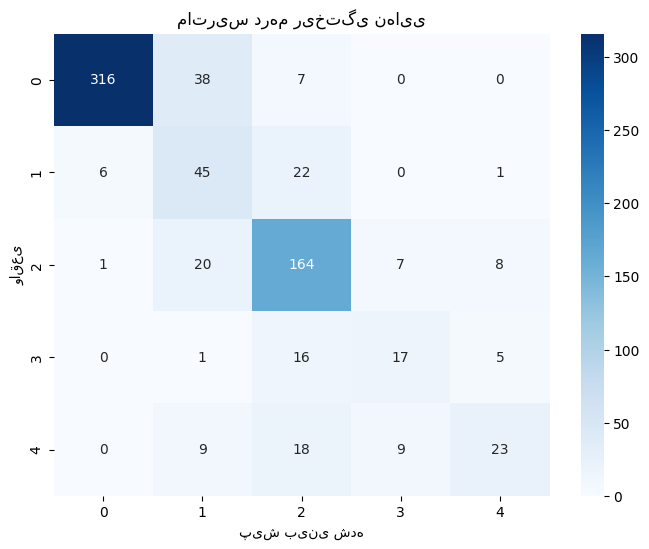


Cohen's Kappa Score (Quadratic) نهایی: 0.8426

--- شروع بصری‌سازی ویژگی‌ها با t-SNE ---
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 346ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


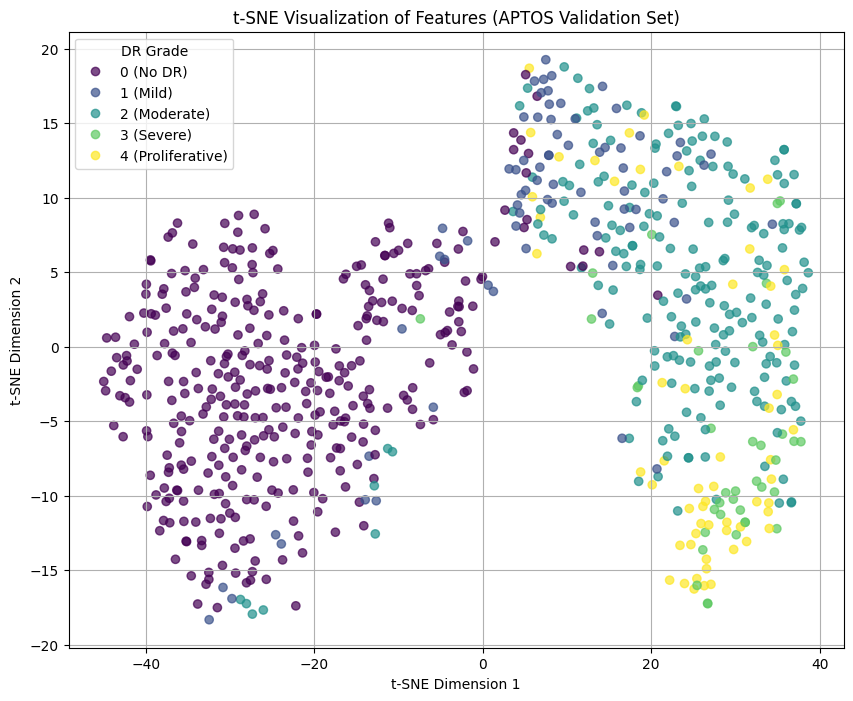


--- بصری‌سازی t-SNE به پایان رسید ---


In [ ]:
# --- 4. Model Evaluation and t-SNE ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs (Fine-tune)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\n--- Final Model Evaluation ---")
val_predictions = model.predict(validation_dataset)
predicted_classes = np.argmax(val_predictions, axis=1)
true_classes = val_df['diagnosis'].values
if len(predicted_classes) != len(true_classes):
    min_len = min(len(predicted_classes), len(true_classes))
    predicted_classes = predicted_classes[:min_len]
    true_classes = true_classes[:min_len]
print("\nFinal Classification Report:")
print(classification_report(true_classes, predicted_classes))
conf_matrix = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(NUM_CLASSES)],
            yticklabels=[str(i) for i in range(NUM_CLASSES)])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Confusion Matrix')
plt.show()
kappa_score = cohen_kappa_score(true_classes, predicted_classes, weights='quadratic')
print(f"\nFinal Cohen's Kappa Score (Quadratic): {kappa_score:.4f}")

# --- Feature Visualization with t-SNE ---
print("\n--- Starting Feature Visualization with t-SNE ---")
try:
    feature_extractor = KerasModel(inputs=model.input, outputs=model.get_layer('Top_Conv').output)
except ValueError:
    feature_extractor = KerasModel(inputs=model.input, outputs=model.layers[-3].output)
val_features = feature_extractor.predict(validation_dataset)
val_labels_tsne = val_df['diagnosis'].values
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_results = tsne.fit_transform(val_features)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=val_labels_tsne, cmap='viridis', alpha=0.7)
classes_names = ['0 (No DR)', '1 (Mild)', '2 (Moderate)', '3 (Severe)', '4 (Proliferative)']
plt.legend(handles=scatter.legend_elements()[0], labels=classes_names, title="DR Grade")
plt.title('t-SNE Visualization of Features (APTOS Validation Set)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True)
plt.show()
print("\n--- t-SNE Visualization completed ---")